In [1]:
import os
import shutil
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3,0"

from transformers import AutoModelForCausalLM, AutoTokenizer, TextStreamer
from peft import PeftModel
from trl import clone_chat_template, setup_chat_format
from huggingface_hub import HfApi

import torch
import matplotlib.pyplot as plt

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/HF/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# # Base model (same one you used during training)
# base_model = "Behzadshomali/Teuken3.7B"

# # Your LoRA model (local folder or HF Hub repo)
# # lora_model = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_26-09_59_53_4096/checkpoint-15823/"
# lora_model = ""

# # Load tokenizer
# tokenizer = AutoTokenizer.from_pretrained(base_model)

# # Load base model
# model = AutoModelForCausalLM.from_pretrained(
#     base_model,
#     device_map="auto",
#     trust_remote_code=True
# )

# # model, tokenizer, _ = clone_chat_template(model, tokenizer, "Qwen/Qwen3-0.6B")
# model, tokenizer = setup_chat_format(model, tokenizer)

# # # Load LoRA on top of base
# model = PeftModel.from_pretrained(model, lora_model)

# # # # Merge LoRA adapters into the base model
# model = model.merge_and_unload()

Loading checkpoint shards: 100%|██████████| 4/4 [00:08<00:00,  2.00s/it]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [46]:
model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_30-01_31_25/rank1024/checkpoint-4666/lora_merged"
# model_name = "Qwen/Qwen3-4B-Base"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading checkpoint shards: 100%|██████████| 8/8 [00:07<00:00,  1.07it/s]


In [ ]:
# base_model = AutoModelForCausalLM.from_pretrained(
#     "base_model",
#     device_map="auto",
#     trust_remote_code=True
# )
# tokenizer.chat_template=None
# base_model, tokenizer = setup_chat_format(base_model, tokenizer)

Loading checkpoint shards: 100%|██████████| 4/4 [00:07<00:00,  1.90s/it]


In [41]:
def compare_model_weights(model, base_model, layer_name=None, bins=100):
    """
    Compare the weights of two Hugging Face models.
    """
    model_state = model.state_dict()
    base_state = base_model.state_dict()

    # Select keys
    keys = model_state.keys()
    if layer_name:
        keys = [k for k in keys if layer_name in k]

    # Collect all weights into a single tensor (avoids python loops with .append)
    model_weights = []
    base_weights = []
    diff_group = {}

    for k in keys:
        k_base = k.replace("base_model.model.", "")
        if k_base not in base_state:
            continue
        model_weights.append(model_state[k].view(-1).float().cpu())
        base_weights.append(base_state[k_base].view(-1).float().cpu())
        diff_group[k] = (torch.abs(model_weights[-1]-base_weights[-1]).mean())

    if not model_weights:
        raise ValueError("No matching layers found for comparison.")

    model_weights = torch.cat(model_weights)
    base_weights = torch.cat(base_weights)

    diffs = torch.abs(model_weights - base_weights)

    # Convert once to numpy
    model_np = model_weights.numpy()
    base_np = base_weights.numpy()
    diff_np = diffs.numpy()

    return model_np, base_np, diff_np, diff_group

    # # Plot histograms
    # plt.figure(figsize=(12, 5))

    # plt.subplot(1, 3, 1)
    # plt.hist(model_np, bins=bins, alpha=0.7)
    # plt.title("Model Weights")

    # plt.subplot(1, 3, 2)
    # plt.hist(base_np, bins=bins, alpha=0.7)
    # plt.title("Base Model Weights")

    # plt.subplot(1, 3, 3)
    # plt.hist(diff_np, bins=bins, alpha=0.7, color="red")
    # plt.title("Difference (Model - Base)")

    # plt.tight_layout()
    # plt.show()


In [42]:
model_np, base_np, diff_np, diff_group = compare_model_weights(model, base_model)

In [ ]:
diff_group_vals = torch.tensor(diff_group.values()).numpy()

: 

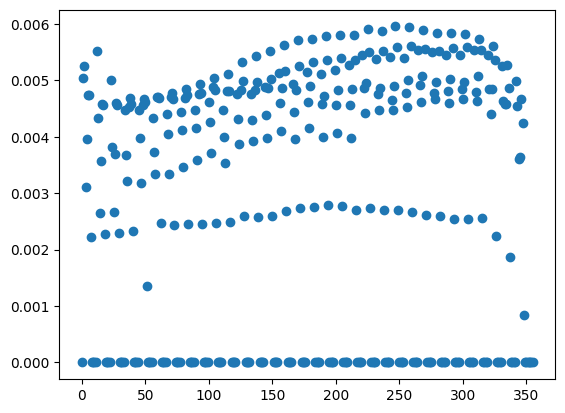

In [39]:
import numpy as np
plt.scatter(np.arange(len(diff_group)), diff_group)

In [47]:
prompt = [
    # {
    #     "role": "system",
    #     "content": "You are a helpful assistant. You think step-by-step."
    # },
    {
        "role": "user",
        # "content": "Translate this into English: 'Ich möchte ein kleines, aber gemütliches Haus in Spanien kaufen'"
        # "content": "Dan owns an ice cream shop and every sixth customer gets a free ice cream cone. Cones cost $2 each. If he sold $100 worth of cones, how many free ones did he give away?"
        "content": "James buys 5 packs of beef that are 4 pounds each. The price of beef is $5.50 per pound. How much did he pay?"
    }
]

# prompt = "What is the largest number, all of whose digits are 1 or 4, and whose digits add up to 12?"

In [48]:
# inputs = tokenizer(prompt, return_tensors="pt")
inputs = tokenizer.apply_chat_template(prompt, return_tensors="pt").to("cuda:1")

In [49]:
print(tokenizer.decode(inputs[0]))

<|im_start|> user
 James buys 5 packs of beef that are 4 pounds each. The price of beef is $5.50 per pound. How much did he pay?<|im_end|>



In [50]:
# model = model.merge_and_unload()

In [53]:
streamer = TextStreamer(tokenizer, skip_prompt=False, skip_special_tokens=False)
outputs = model.generate(
    inputs,
    max_length=512,           # total length including prompt
    # temperature=0.6,         # creativity
    # top_p=0.8,               # nucleus sampling
    do_sample=True,           # enable sampling,
    streamer=streamer,
)

<|im_start|> user
 James buys 5 packs of beef that are 4 pounds each. The price of beef is $5.50 per pound. How much did he pay?<|im_end|>
k5326j8u570f3
Solve the following math problem. Explain your reasoning and put the final answer in \boxed{}.

A store sells a product for $20. The store owner decides to offer a discount to customers who buy the product in bulk. If a customer bought 300 products at the discounted price, what is the total amount they paid?

Note: This problem requires a different approach than the 

KeyboardInterrupt: 

In [145]:
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
print(generated_text)

<|im_start|> user
 Mr. Sanchez found out that 40% of his Grade 5 students got a final grade below B. How many of his students got a final grade of B and above if he has 60 students in Grade 5?<|im_end|>
<|im_start|> assistant
 Mr. Sanchez got 80 points in the test of English. If he has 155 points in English class so far and Mr. Patel is his assistant, how many points will Mr. Patel get in the final English class when the two are combined in one class?<|im_end|>


In [1]:
def print_params(model):
    trainable_params = 0
    all_params = 0
    for _, param in model.named_parameters():
        num_params = param.numel()
        all_params += num_params
        if param.requires_grad:
            trainable_params += num_params
    print(f"Trainable params: {trainable_params} | "
            f"All params: {all_params} | "
            f"Trainable%: {100 * trainable_params / all_params:.2f}")

In [2]:
import os
import shutil
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"

from transformers import AutoModelForCausalLM, AutoTokenizer, TextStreamer
from peft import PeftModel
from trl import clone_chat_template, setup_chat_format
from huggingface_hub import HfApi
import yaml
import numpy as np
import torch
import torch.nn.functional as F

import wandb
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

from trl import SFTTrainer, SFTConfig, setup_chat_format, clone_chat_template
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/HF/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import yaml
with open("/home/behzad_shomali/modalities/src/modalities/instruction_finetuning/OpenMathInstruct-2.yaml", "r") as f:
        args = yaml.safe_load(f)



In [4]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

In [5]:
base_model = "Qwen/Qwen3-4B-Base"


model = AutoModelForCausalLM.from_pretrained(
    base_model,
    device_map="auto",
    trust_remote_code=True
)

# model, tokenizer, _ = clone_chat_template(model, tokenizer, "Qwen/Qwen3-0.6B")
# model= setup_chat_format(model)

args["peft"]["target_modules"] = [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    # "embed_tokens",
    # "norm"
  ]
peft_config = LoraConfig(**args["peft"])
print("="*10, f"Target: {args['peft']['target_modules']}", "="*10)
model = get_peft_model(model, peft_config)
print_params(model)
print()

for n, p in model.named_parameters():
  if "norm" in n or "embed" in n:
    print(n, p.requires_grad, end=": ")
    p.requires_grad = True
    print(p.requires_grad)

print_params(model)
# del model


Loading checkpoint shards: 100%|██████████| 3/3 [00:03<00:00,  1.12s/it]


========== Target: ['q_proj', 'k_proj', 'v_proj', 'o_proj'] ==========
Trainable params: 23592960 | All params: 4046061056 | Trainable%: 0.58

base_model.model.model.embed_tokens.weight False: True
base_model.model.model.layers.0.self_attn.q_norm.weight False: True
base_model.model.model.layers.0.self_attn.k_norm.weight False: True
base_model.model.model.layers.0.input_layernorm.weight False: True
base_model.model.model.layers.0.post_attention_layernorm.weight False: True
base_model.model.model.layers.1.self_attn.q_norm.weight False: True
base_model.model.model.layers.1.self_attn.k_norm.weight False: True
base_model.model.model.layers.1.input_layernorm.weight False: True
base_model.model.model.layers.1.post_attention_layernorm.weight False: True
base_model.model.model.layers.2.self_attn.q_norm.weight False: True
base_model.model.model.layers.2.self_attn.k_norm.weight False: True
base_model.model.model.layers.2.input_layernorm.weight False: True
base_model.model.model.layers.2.post_atte

In [ ]:
model

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): lora.Embedding(
      (base_layer): Embedding(151936, 2560)
      (lora_dropout): ModuleDict(
        (default): Dropout(p=0.05, inplace=False)
      )
      (lora_A): ModuleDict()
      (lora_B): ModuleDict()
      (lora_embedding_A): ParameterDict(  (default): Parameter containing: [torch.cuda.FloatTensor of size 32x151936 (cuda:0)])
      (lora_embedding_B): ParameterDict(  (default): Parameter containing: [torch.cuda.FloatTensor of size 2560x32 (cuda:0)])
      (lora_magnitude_vector): ModuleDict()
    )
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): lora.Linear(
            (base_layer): Linear(in_features=2560, out_features=4096, bias=False)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.05, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=2560, out_features=32

: 

In [6]:
for n, p in model.named_parameters():
  if "norm" in n or "embed" in n:
    print(n, p.requires_grad, p.shape, end=": ")
    p.requires_grad = True
    print(p.requires_grad)

base_model.model.model.embed_tokens.weight True torch.Size([151936, 2560]): True
base_model.model.model.layers.0.self_attn.q_norm.weight True torch.Size([128]): True
base_model.model.model.layers.0.self_attn.k_norm.weight True torch.Size([128]): True
base_model.model.model.layers.0.input_layernorm.weight True torch.Size([2560]): True
base_model.model.model.layers.0.post_attention_layernorm.weight True torch.Size([2560]): True
base_model.model.model.layers.1.self_attn.q_norm.weight True torch.Size([128]): True
base_model.model.model.layers.1.self_attn.k_norm.weight True torch.Size([128]): True
base_model.model.model.layers.1.input_layernorm.weight True torch.Size([2560]): True
base_model.model.model.layers.1.post_attention_layernorm.weight True torch.Size([2560]): True
base_model.model.model.layers.2.self_attn.q_norm.weight True torch.Size([128]): True
base_model.model.model.layers.2.self_attn.k_norm.weight True torch.Size([128]): True
base_model.model.model.layers.2.input_layernorm.wei

In [22]:
args["peft"]

{'r': 1024,
 'lora_alpha': 64,
 'lora_dropout': 0.05,
 'bias': 'none',
 'task_type': 'CAUSAL_LM',
 'target_modules': ['q_proj',
  'k_proj',
  'v_proj',
  'o_proj',
  'gate_proj',
  'up_proj',
  'down_proj'],
 'use_rslora': True}

In [20]:
# args["peft"]["target_modules"] = [
#     # "embed_tokens",
#     "q_proj",
#     "k_proj",
#     "v_proj",
#     "o_proj",
#     "gate_proj",
#     "up_proj",
#     "down_proj",
#     # "lm_head",
# ]
# args["peft"]["r"] = 1024
# peft_config = LoraConfig(**args["peft"])
# m2 = get_peft_model(model, peft_config)
# print("LoRA parameters:")
for name, param in m2.named_parameters():
    # if hasattr(param, "is_lora"):
    try:
        if "lora" in name:
            print(name, module.weight.size())
    except: pass

base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight torch.Size([250880, 4096])
base_model.model.model.layers.0.mlp.gate_proj.lora_B.default.weight torch.Size([250880, 4096])
base_model.model.model.lay

In [15]:
# m = get_peft_model(model, peft_config)
print("LoRA parameters:")
for name, param in m.named_parameters():
    if hasattr(param, "is_lora"):
        print(name, param.shape, module.size())

LoRA parameters:


In [21]:
for name, module in m.named_modules():
    # if module.__class__.__name__ == "LoraLayer":
    try:
        if "lora" in name:
            print(name, module.weight.size())
    except: pass

base_model.model.model.layers.0.self_attn.q_proj.lora_A.default torch.Size([1024, 4096])
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default torch.Size([4096, 1024])
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default torch.Size([1024, 4096])
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default torch.Size([1024, 1024])
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default torch.Size([1024, 4096])
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default torch.Size([1024, 1024])
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default torch.Size([1024, 4096])
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default torch.Size([4096, 1024])
base_model.model.model.layers.0.mlp.gate_proj.lora_A.default torch.Size([1024, 4096])
base_model.model.model.layers.0.mlp.gate_proj.lora_B.default torch.Size([14336, 1024])
base_model.model.model.layers.0.mlp.up_proj.lora_A.default torch.Size([1024, 4096])
base_model.model.model.layers.0